# Module 10: Coalescing Particles on a Circle

This exploratory module is motivated by the coalescent models in Chapter 5 of the lecture notes. In Kingman's coalescent, ancestral lineages merge backward in time until only one lineage remains.

Here we study an alternative particle model on a finite circle. Several particles move randomly on the circle, and when two particles meet, they merge into one cluster. The number of clusters can stay the same or decrease at each step, and the simulation stops when only one cluster remains.

This is not the same model as Kingman's coalescent. In the present model, a merger depends on the positions of clusters on the circle. The purpose is to visualize the same basic coalescence idea: many active objects evolve randomly and gradually merge into fewer objects.

## Model

The state space is a circle with $m$ sites, labelled $0,1,\ldots,m-1$. Initially, $k$ distinct sites are occupied by particles.

At each step, one current cluster is chosen uniformly at random. It then moves one step clockwise or one step counterclockwise, each with probability $1/2$. If the new site is empty, the cluster moves there. If the new site is already occupied, the two clusters merge.

Each occupied site represents one cluster. The simulation does not record how many original particles belong to a cluster. We record the number of occupied sites after each step, and the process stops when only one cluster remains.

### Connection with coalescent models

In Kingman's coalescent, the main quantity is the number of ancestral lineages. This number decreases by one whenever two lineages merge. In this notebook, the number of occupied sites plays a similar visual role. Unlike Kingman's model, mergers here depend on the spatial positions of the clusters.

The state of the particle system is not just the number of clusters. To know the next possible changes, we also need to know where the clusters are on the circle. Thus the natural state is the whole set of occupied sites.

### Simulation rule

Choose $k$ distinct initial sites on a circle of size $m$. At each step, choose one occupied site uniformly at random and move its cluster one step clockwise or counterclockwise. If the new site is empty, the cluster moves there. If the new site is occupied, the two clusters merge and the number of occupied sites decreases by one. The simulation stops when only one occupied site remains.


## Libraries

We first import the libraries used in this module. NumPy is used to choose moving clusters, update occupied sites, and repeat simulations. Matplotlib is used to show particle configurations, cluster count paths, and the distribution of coalescence times.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from IPython.display import clear_output

In [12]:
FIGSIZE = (8, 4.5)
HIST_ALPHA = 0.65

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False
plt.rcParams["lines.markersize"] = 4

# Random generator
rng = np.random.default_rng()

### Helper functions

The following functions simulate the coalescing particle system and plot particle configurations on the circle.

In [13]:
def initial_positions_circle(m, k, rng=None):
    """Choose k distinct initial sites on a circle."""
    if m < 1:
        raise ValueError("m must be positive.")
    if k < 1 or k > m:
        raise ValueError("k must satisfy 1 <= k <= m.")

    if rng is None:
        rng = np.random.default_rng()

    return np.sort(rng.choice(m, size=k, replace=False))

def simulate_coalescing_particles_circle(m, k, max_steps=10_000, rng=None):
    """Simulate coalescing particles on a circle."""
    if rng is None:
        rng = np.random.default_rng()

    positions = set(initial_positions_circle(m, k, rng=rng))

    history = [np.array(sorted(positions))]
    counts = [len(positions)]

    for _ in range(max_steps):
        # Stop when one cluster remains
        if len(positions) == 1:
            break

        # Choose the cluster that moves next
        pos_list = sorted(positions)
        old_pos = pos_list[rng.integers(len(pos_list))]

        # Move clockwise or counterclockwise
        direction = rng.choice([-1, 1])
        new_pos = (old_pos + direction) % m

        # Remove old position
        positions.remove(old_pos)

        # Merge automatically if new_pos is occupied
        positions.add(new_pos)

        history.append(np.array(sorted(positions)))
        counts.append(len(positions))

    # A capped run has no observed coalescence time
    coalescence_time = len(counts) - 1 if len(positions) == 1 else None

    return history, np.array(counts), coalescence_time

def plot_circle_configuration(positions, m, ax=None, title=None):
    """Plot occupied sites on a circle."""
    if ax is None:
        ax = plt.gca()

    theta_sites = 2 * np.pi * np.arange(m) / m
    x_sites = np.cos(theta_sites)
    y_sites = np.sin(theta_sites)

    ax.scatter(
        x_sites,
        y_sites,
        s=25,
        alpha=0.5,
        label="circle sites"
    )

    theta_occ = 2 * np.pi * positions / m
    x_occ = np.cos(theta_occ)
    y_occ = np.sin(theta_occ)

    ax.scatter(
        x_occ,
        y_occ,
        s=90,
        label="occupied sites"
    )

    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=1)

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    if title is not None:
        ax.set_title(title)

## Example 1: One coalescing system

We first simulate one realization of the particle system. A single run gives one sample path of the number of clusters over time.

The process starts with $k$ occupied sites. The number of clusters stays constant when a cluster moves to an empty site, and decreases by one when a cluster moves onto an occupied site.

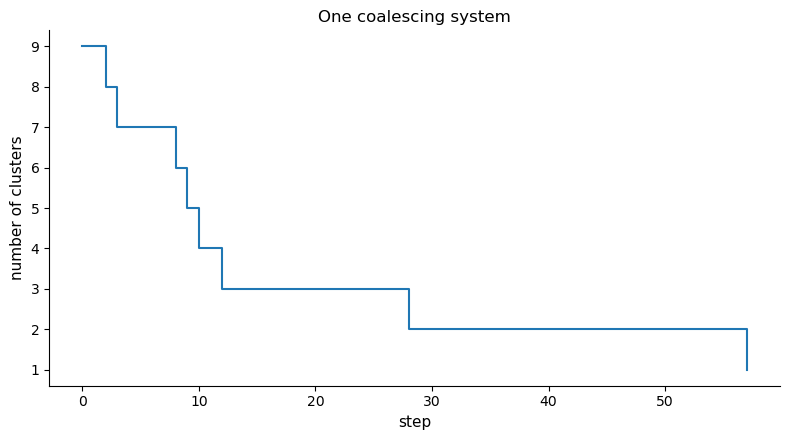

Circle size: 12
Initial number of particles: 9
Final number of clusters: 1
Coalescence time: 57


In [14]:
m_example = 12
k_example = 9
max_steps_example = 5000

history, counts, coalescence_time = simulate_coalescing_particles_circle(
    m=m_example,
    k=k_example,
    max_steps=max_steps_example,
    rng=rng
)

plt.figure(figsize=FIGSIZE)

plt.step(
    np.arange(len(counts)),
    counts,
    where="post"
)

plt.xlabel("step")
plt.ylabel("number of clusters")
plt.title("One coalescing system")
plt.tight_layout()
plt.show()

print("Circle size:", m_example)
print("Initial number of particles:", k_example)
print("Final number of clusters:", counts[-1])
print("Coalescence time:", coalescence_time)

This figure shows one simulated path of the cluster count. It is not an empirical distribution.

The path is non-increasing because one update can only leave the number of clusters unchanged or reduce it by one. A downward jump occurs when the moving cluster lands on an already occupied site and merges with that cluster.

## Example 2: Configurations on the circle

The cluster count records how many occupied sites remain, but it does not show where the clusters are. To see the spatial part of the model, we plot selected configurations on the circle.

Each marked occupied site represents one current cluster. When a moving cluster reaches another occupied site, the number of occupied sites decreases.

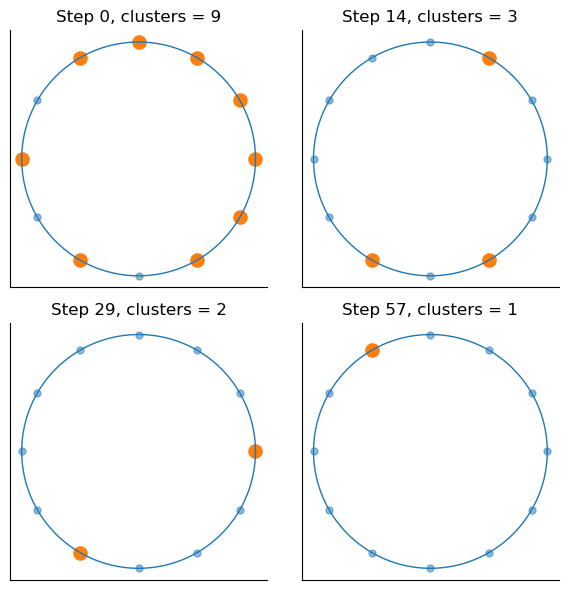

In [15]:
snapshot_steps = [
    0,
    len(history) // 4,
    len(history) // 2,
    len(history) - 1
]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for ax, step in zip(axes.ravel(), snapshot_steps):
    plot_circle_configuration(
        history[step],
        m_example,
        ax=ax,
        title=f"Step {step}, clusters = {len(history[step])}"
    )

plt.tight_layout()
plt.show()

The snapshots show the spatial evolution of one simulation. At the beginning, many sites are occupied. As the dynamics continues, particles move on the circle and some of them meet and merge.

This plot complements the cluster-count path. The step plot shows how many clusters remain, while the circle plots show where those clusters are located.

### Interactive view

The next cell lets us move through the same simulated path step by step. This is useful because the static snapshots only show a few selected times.

In [ ]:

def show_configuration(t):
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(4, 4))

    plot_circle_configuration(
        history[t],
        m_example,
        ax=ax,
        title=f"Step {t}, clusters = {len(history[t])}"
    )

    plt.tight_layout()
    plt.show()

interact(
    show_configuration,
    t=IntSlider(min=0, max=len(history) - 1, step=1, value=0)
);

interactive(children=(IntSlider(value=0, description='t', max=57), Output()), _dom_classes=('widget-interact',…

The slider shows that coalescence does not occur at every step. Many moves only change the position of a cluster, while the number of clusters stays the same. A coalescence event occurs only when a moving cluster lands on an occupied site.

## Example 3: Distribution of coalescence time

A single simulation gives one coalescence time. To understand how variable this time is, we repeat the simulation many times.

Here the coalescence time means the number of simulation steps needed until only one cluster remains. This is an absorption time for the particle system.

In [17]:
n_runs = 3000
m_runs = 12
k_runs = 9
max_steps_runs = 10000

# Store only runs that reach one cluster
coalescence_times = []
not_finished = 0

for _ in range(n_runs):
    history_run, counts_run, time_run = simulate_coalescing_particles_circle(
        m=m_runs,
        k=k_runs,
        max_steps=max_steps_runs,
        rng=rng
    )

    if time_run is None:
        not_finished += 1
    else:
        coalescence_times.append(time_run)

coalescence_times = np.array(coalescence_times)
if len(coalescence_times) == 0:
    raise RuntimeError("No run reached one cluster before max_steps.")

print("Number of simulations:", n_runs)
print("Circle size:", m_runs)
print("Initial number of particles:", k_runs)
print("Average coalescence time:", coalescence_times.mean())
print("Median coalescence time:", np.median(coalescence_times))
print("Minimum coalescence time:", coalescence_times.min())
print("Maximum coalescence time:", coalescence_times.max())
print("Runs not finished before max_steps:", not_finished)

Number of simulations: 3000
Circle size: 12
Initial number of particles: 9
Average coalescence time: 62.55233333333333
Median coalescence time: 56.0
Minimum coalescence time: 13
Maximum coalescence time: 287
Runs not finished before max_steps: 0


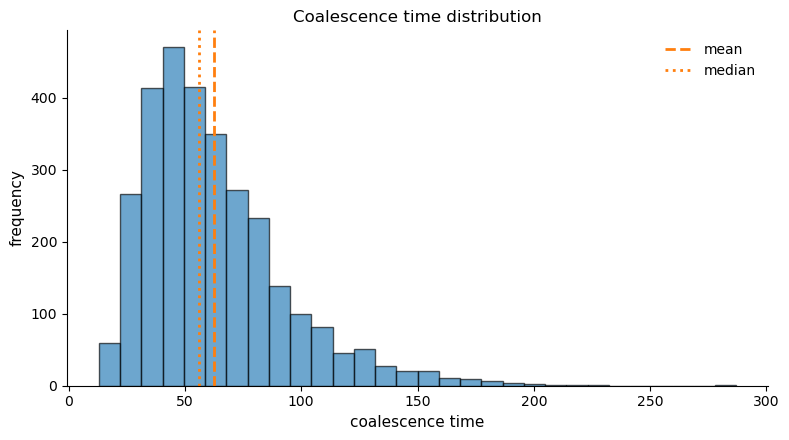

In [18]:
# Mean and median coalescence times
mean_time = coalescence_times.mean()
median_time = np.median(coalescence_times)

plt.figure(figsize=FIGSIZE)

# Histogram of coalescence times
plt.hist(
    coalescence_times,
    bins=30,
    alpha=HIST_ALPHA,
    edgecolor="black"
)

# Add reference lines for mean and median
plt.axvline(
    mean_time,
    color="C1",
    linestyle="--",
    linewidth=2,
    label="mean"
)

plt.axvline(
    median_time,
    color="C1",
    linestyle=":",
    linewidth=2,
    label="median"
)

plt.xlabel("coalescence time")
plt.ylabel("frequency")
plt.title("Coalescence time distribution")
plt.legend()
plt.tight_layout()
plt.show()

This histogram is based on many simulations with the same values of $m$ and $k$. Each run gives one coalescence time.

The distribution shows that the time until one cluster remains is random. Some systems coalesce quickly, while others take much longer because particles may move for many steps before meeting. The mean and median lines give two simple summaries of the distribution.

## Example 4: Occupied sites over time

The circle snapshots show selected configurations from one simulation. We can also record the whole simulation in a time-by-site table.

In the next plot, the horizontal axis shows the simulation step, and the vertical axis shows the circle site. A gray entry means that the site is empty at that step, while an orange entry means that the site is occupied.

In [19]:
# Number of recorded steps in the simulation
n_recorded_steps = len(history)

# Create a matrix with one row for each step
# and one column for each site on the circle
occupancy = np.zeros((n_recorded_steps, m_example))

for step, positions in enumerate(history):
    occupancy[step, positions] = 1

print("Number of recorded steps:", n_recorded_steps)
print("Circle size:", m_example)
print("Occupancy matrix shape:", occupancy.shape)

Number of recorded steps: 58
Circle size: 12
Occupancy matrix shape: (58, 12)


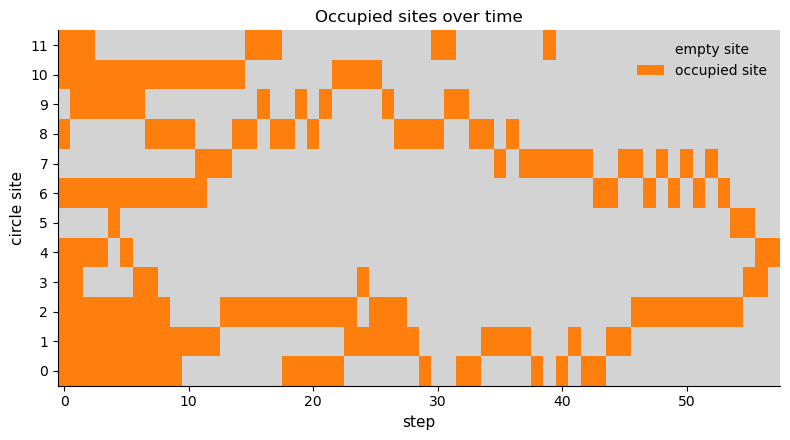

In [20]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

plt.figure(figsize=FIGSIZE)

cmap = ListedColormap(["lightgray", "C1"])

# Transpose occupancy so that step is on the x-axis
plt.imshow(
    occupancy.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap=cmap,
    vmin=0,
    vmax=1
)

plt.xlabel("step")
plt.ylabel("circle site")
plt.title("Occupied sites over time")

# Use integer ticks for circle sites
plt.yticks(np.arange(m_example))

# Add a legend explaining the two colors
legend_elements = [
    Patch(facecolor="lightgray", label="empty site"),
    Patch(facecolor="C1", label="occupied site")
]

plt.legend(
    handles=legend_elements,
    loc="upper right"
)

plt.tight_layout()
plt.show()

This plot records one complete simulation. The horizontal axis gives the simulation step, and the vertical axis gives the site number on the circle. Since the sites are arranged on a circle, site 0 is adjacent to site \(m-1\).

At early steps, several sites are occupied. As particles move and coalesce, fewer occupied sites remain. The plot gives a compact view of both movement and merging during one simulation.